# Life Expectancy (WHO) Dataset - Data Analysis Project


## 1. Import Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
sns.set_style("whitegrid")


## 2. Load the Dataset

In [2]:

df = pd.read_csv("Life Expectancy Data.csv")
print("Shape of data:", df.shape)
df.head()

Shape of data: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
# remove extra spaces from column names
df.columns = df.columns.str.strip()
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='str')

## 3. Clean the Data

In [4]:
df.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [5]:
#only numeric columns to fill missing values
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
df.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 4. Exploratory Data Analysis (EDA)

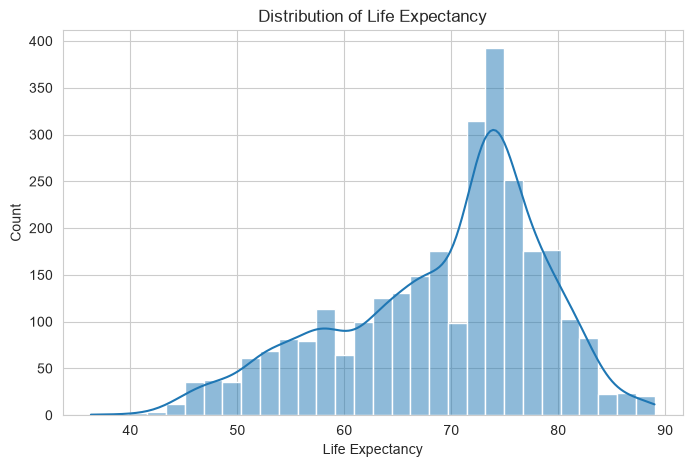

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Life expectancy"], bins=30, kde=True)
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.show()

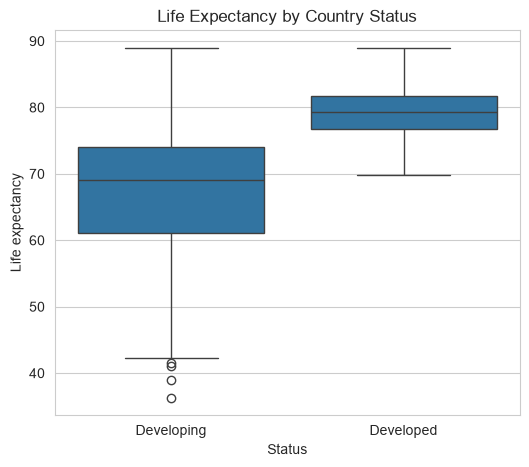

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x="Status",y="Life expectancy",data=df)
plt.title("Life Expectancy by Country Status")
plt.show()

In [9]:
corr = df[numeric_cols].corr()
corr["Life expectancy"].abs().sort_values(ascending=False)

Life expectancy                    1.000000
Schooling                          0.713054
Adult Mortality                    0.696390
Income composition of resources    0.688662
BMI                                0.556901
HIV/AIDS                           0.556703
Diphtheria                         0.472211
thinness  1-19 years               0.468002
thinness 5-9 years                 0.462473
Polio                              0.458399
GDP                                0.430461
Alcohol                            0.388918
percentage expenditure             0.381418
under-five deaths                  0.222738
Total expenditure                  0.208844
infant deaths                      0.196769
Year                               0.170819
Hepatitis B                        0.170219
Measles                            0.157767
Population                         0.029014
Name: Life expectancy, dtype: float64

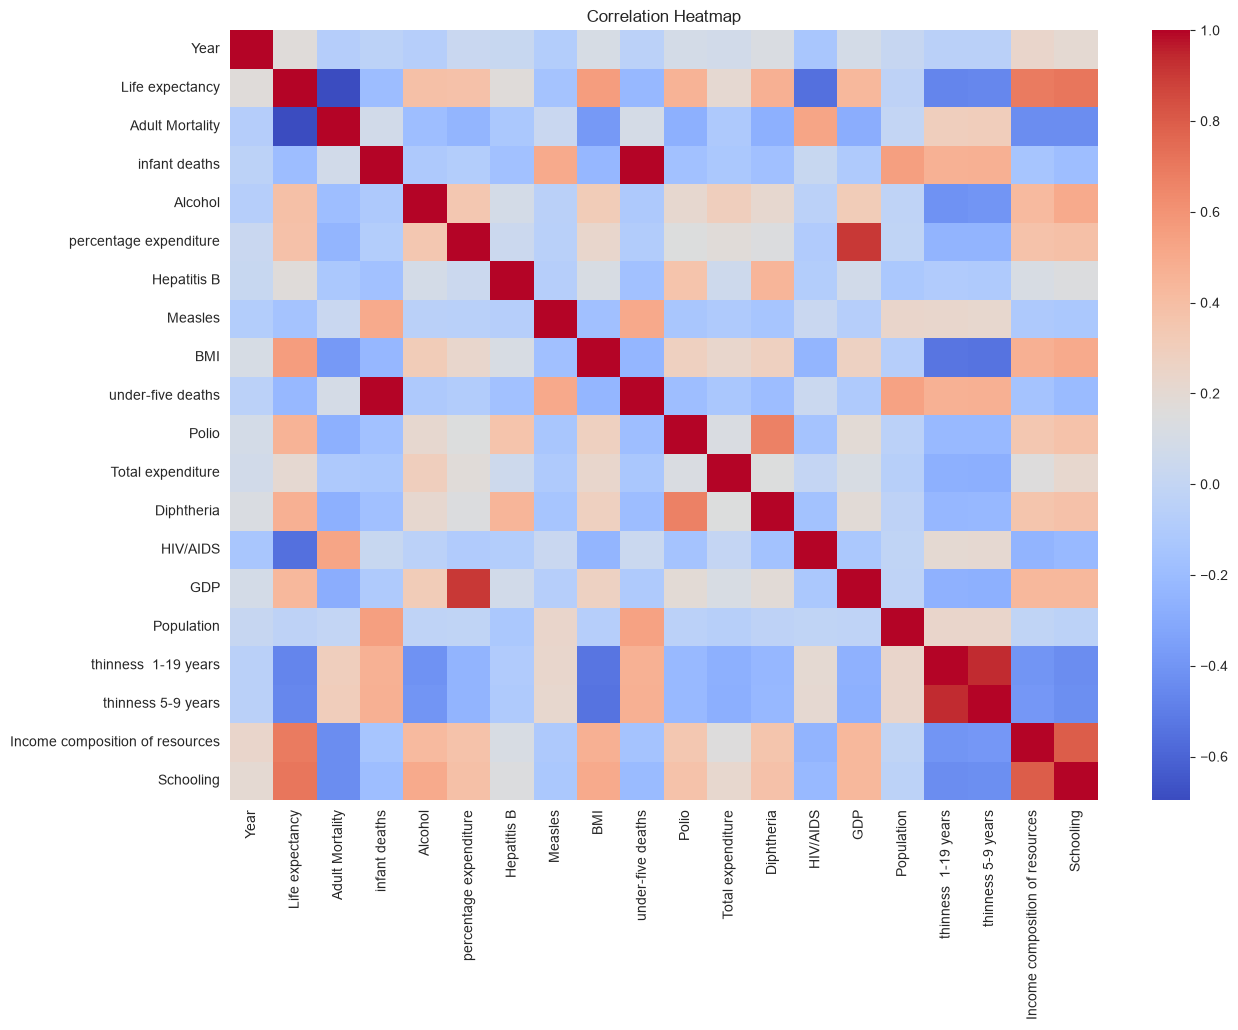

In [10]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

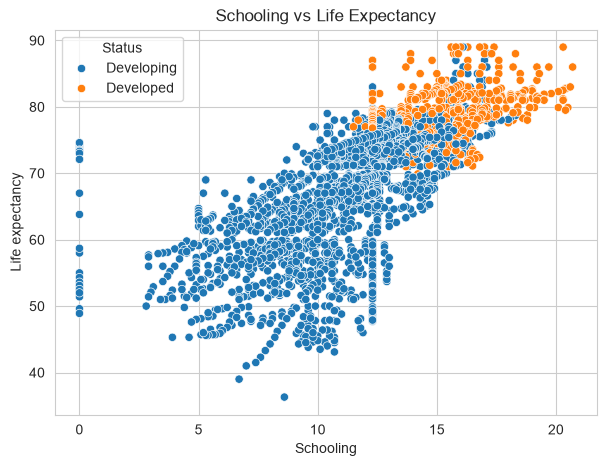

In [11]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Schooling", y="Life expectancy", hue="Status", data=df)
plt.title("Schooling vs Life Expectancy")
plt.show()

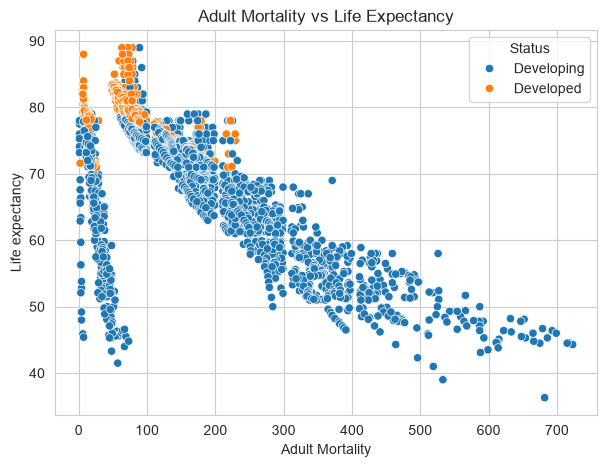

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Adult Mortality",y="Life expectancy",hue="Status",data=df)
plt.title("Adult Mortality vs Life Expectancy")
plt.show()

## 5. Feature Selection


In [13]:
relevant_cols = [
    "Status",
    "Adult Mortality",
    "BMI",
    "HIV/AIDS",
    "Diphtheria",
    "thinness  1-19 years",
    "Polio",
    "GDP",
    "Alcohol",
    "Income composition of resources",
    "Schooling",
    "Life expectancy"
]
model_df=df[relevant_cols].copy()
model_df["Status"]=model_df["Status"].map({"Developing": 0, "Developed": 1})  #mapping
model_df.head()

,Status,Adult Mortality,BMI,HIV/AIDS,Diphtheria,thinness 1-19 years,Polio,GDP,Alcohol,Income composition of resources,Schooling,Life expectancy
0,0,263.0,19.1,0.1,65.0,17.2,6.0,584.259210,0.01,0.479,10.1,65.0
1,0,271.0,18.6,0.1,62.0,17.5,58.0,612.696514,0.01,0.476,10.0,59.9
2,0,268.0,18.1,0.1,64.0,17.7,62.0,631.744976,0.01,0.470,9.9,59.9
3,0,272.0,17.6,0.1,67.0,17.9,67.0,669.959000,0.01,0.463,9.8,59.5
4,0,275.0,17.2,0.1,68.0,18.2,68.0,63.537231,0.01,0.454,9.5,59.2


## 6. Regression Task - Predict Life Expectancy

In [16]:
X_reg=model_df.drop(columns=["Life expectancy"])
y_reg=model_df["Life expectancy"]
X_train,X_test,y_train,y_test=train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)
print("Trainsize:",X_train.shape)
print("Testsize:",X_test.shape)

Trainsize: (2350, 11)
Testsize: (588, 11)


In [ ]:
models_need_scaling={"Linear Regression"}
def run_regression_model(model,name):
    if name in models_need_scaling:    #adding scaling to piplenie whoever model requier it
        pipe = Pipeline([
            ("scaler",StandardScaler()),
            ("model",model)
        ])
    else:
        pipe=Pipeline([
            ("model", model)
        ])
    pipe.fit(X_train,y_train)
    preds=pipe.predict(X_test)
    r2=r2_score(y_test,preds)
    rmse=np.sqrt(mean_squared_error(y_test,preds))
    mae= mean_absolute_error(y_test,preds)
    print(name," R2:",round(r2,3)," RMSE:",round(rmse,3)," MAE:",round(mae,3))
    return pipe, r2, rmse, mae

In [18]:
# train Linear Regression pipeline 
lr_pipe, lr_r2, lr_rmse, lr_mae = run_regression_model(LinearRegression(), "Linear Regression")

Linear Regression  R2: 0.813  RMSE: 4.03  MAE: 2.928


In [19]:
# train Decision Tree Regressor pipelinee
dt_pipe,dt_r2,dt_rmse,   dt_mae=run_regression_model(DecisionTreeRegressor(random_state=42),"Decision Tree")

Decision Tree  R2: 0.922  RMSE: 2.596  MAE: 1.589


In [20]:
# train Random Forest Regressor pipeline
rf_pipe,rf_r2,rf_rmse,rf_mae=run_regression_model(RandomForestRegressor(random_state=42),"Random Forest")

Random Forest  R2: 0.967  RMSE: 1.687  MAE: 1.118


In [21]:
reg_results=pd.DataFrame({
    "Model":["Linear Regression","Decision Tree","Random Forest"],
    "R2 Score":[lr_r2, dt_r2, rf_r2],
    "RMSE":[lr_rmse, dt_rmse, rf_rmse],
    "MAE":[lr_mae, dt_mae, rf_mae]
})
reg_results

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.812642,4.029619,2.928220
1,Decision Tree,0.922265,2.595591,1.588605
2,Random Forest,0.967167,1.686885,1.117701


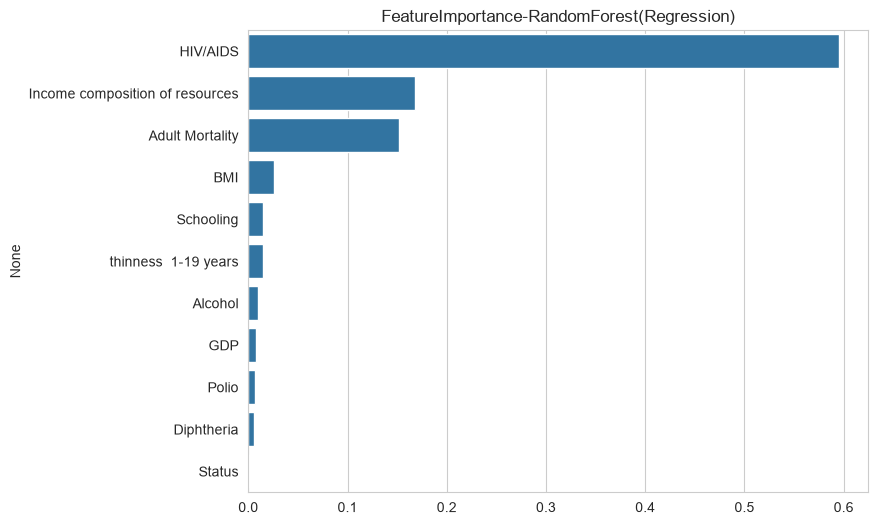

In [22]:
# check which features are most important for the Random Forest modelll #####
importances=rf_pipe.named_steps["model"].feature_importances_
feat_imp=pd.Series(importances,index=X_reg.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values,y=feat_imp.index)
plt.title("FeatureImportance-RandomForest(Regression)")
plt.show()

## 7. Classification Task - Predict Country Status

In [23]:
X_clf=model_df.drop(columns=["Status"])
y_clf=model_df["Status"]
Xc_train,Xc_test,yc_train,yc_test=train_test_split(X_clf,y_clf,test_size=0.2,random_state=42,stratify=y_clf)
print("Trainsize:",Xc_train.shape)
print("Testsize:",Xc_test.shape)

Trainsize: (2350, 11)
Testsize: (588, 11)


In [24]:
clf_models_need_scaling={"Logistic Regression","KNN","SVM"}
def run_classification_model(model,name):
    if name in clf_models_need_scaling:
        pipe=Pipeline([
            ("scaler",StandardScaler()),
            ("model",model)
        ])
    else:
        pipe=Pipeline([
            ("model",model)
        ])
    pipe.fit(Xc_train, yc_train)
    preds=pipe.predict(Xc_test)
    acc=accuracy_score(yc_test,preds)
    prec=precision_score(yc_test,preds)
    rec=recall_score(yc_test,preds)
    f1=f1_score(yc_test,preds)
    print(name," Accuracy:",round(acc,3)," Precision:",round(prec,3)," Recall:",round(rec,3),"F1:",round(f1,3))
    return pipe, acc, prec, rec, f1

In [25]:
# train Logistic Regression pipeline (gets scaling)
log_pipe,log_acc,log_prec,log_rec,log_f1=run_classification_model(LogisticRegression(max_iter=1000),"LogisticRegression")

LogisticRegression  Accuracy: 0.92  Precision: 0.824  Recall: 0.686 F1: 0.749


c:\Users\LENOVO\Documents\GitHub\project\.venv_life_expectancy\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
# train Decision Tree Classifier pipeline (no scaling needed)
dtc_pipe,dtc_acc,dtc_prec,dtc_rec,dtc_f1=run_classification_model(DecisionTreeClassifier(random_state=42),"DecisionTree")

DecisionTree  Accuracy: 0.966  Precision: 0.91  Recall: 0.892 F1: 0.901


In [27]:
# train Random Forest Classifier pipeline (no scaling needed)
rfc_pipe,rfc_acc,rfc_prec,rfc_rec,rfc_f1=run_classification_model(RandomForestClassifier(random_state=42),"RandomForest")

RandomForest  Accuracy: 0.978  Precision: 0.941  Recall: 0.931 F1: 0.936


In [28]:
# train K-Nearest Neighbors pipeline (gets scaling)
knn_pipe,knn_acc,knn_prec,knn_rec,knn_f1=run_classification_model(KNeighborsClassifier(),"KNN")

KNN  Accuracy: 0.949  Precision: 0.919  Recall: 0.775 F1: 0.84


In [29]:
# train Support Vector Machine pipeline (gets scaling, probability=True lets us get confidence scores later)
svm_pipe,svm_acc,svm_prec,svm_rec,svm_f1=run_classification_model(SVC(probability=True,random_state=42),"SVM")

SVM  Accuracy: 0.951  Precision: 0.869  Recall: 0.843 F1: 0.856


c:\Users\LENOVO\Documents\GitHub\project\.venv_life_expectancy\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [30]:
clf_results =pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest","KNN","SVM"],
    "Accuracy":[log_acc, dtc_acc, rfc_acc, knn_acc, svm_acc],
    "Precision":[log_prec, dtc_prec, rfc_prec, knn_prec, svm_prec],
    "Recall":[log_rec, dtc_rec, rfc_rec, knn_rec, svm_rec],                           #comparison DataFrame
    "F1 Score":[log_f1, dtc_f1, rfc_f1, knn_f1, svm_f1]
})
clf_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.920068,0.823529,0.686275,0.748663
1,Decision Tree,0.965986,0.910000,0.892157,0.900990
2,Random Forest,0.977891,0.940594,0.931373,0.935961
3,KNN,0.948980,0.918605,0.774510,0.840426
4,SVM,0.950680,0.868687,0.843137,0.855721


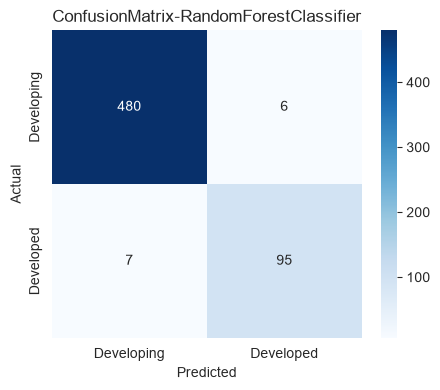

In [ ]:
preds=rfc_pipe.predict(Xc_test)
cm=confusion_matrix(yc_test,preds)
#confusionmatrix plot
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Developing","Developed"],yticklabels=["Developing","Developed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ConfusionMatrix-RandomForestClassifier")
plt.show()

In [32]:
#full classification report for the Random Forest model
print(classification_report(yc_test,preds,target_names=["Developing","Developed"]))

              precision    recall  f1-score   support

  Developing       0.99      0.99      0.99       486
   Developed       0.94      0.93      0.94       102

    accuracy                           0.98       588
   macro avg       0.96      0.96      0.96       588
weighted avg       0.98      0.98      0.98       588



## 8. Save Models and Data


In [33]:
model_df.to_csv("cleaned_life_expectancy.csv",index=False)

joblib.dump(lr_pipe,"reg_linear_regression.pkl")
joblib.dump(dt_pipe,"reg_decision_tree.pkl")             #regressionmodels
joblib.dump(rf_pipe,"reg_random_forest.pkl")
joblib.dump(log_pipe,"clf_logistic_regression.pkl")
joblib.dump(dtc_pipe,"clf_decision_tree.pkl")          #classificationmodels
joblib.dump(rfc_pipe,"clf_random_forest.pkl")
joblib.dump(knn_pipe,"clf_knn.pkl")
joblib.dump(svm_pipe,"clf_svm.pkl")
print("All models and data saved successfully")

All models and data saved successfully
